# Append Tracking: Extending Existing Trajectories with New NEXRAD Data

This notebook demonstrates how to use `tobac.tracking.append_tracks_trackpy` to extend an existing tracking dataset forward in time.

This notebook demonstrates:
- How to load NEXRAD Level-2 data from the NOAA AWS open-data archive using `s3fs` and `Py-ART`
- How to grid the raw radar data and prepare it for *tobac*
- How to perform an initial tracking run on the first half of a radar dataset
- How to append a second batch of data onto those existing tracks using `tobac.tracking.append_tracks_trackpy`
- How to verify that cell numbers are consistent across the join boundary

**Note:** In addition to the normal tobac requirements, this notebook also requires that
`Py-ART`, `s3fs`, and `cartopy` are installed.


## Library Imports

In [1]:
from datetime import datetime, timedelta
from pathlib import Path

import numpy as np
import pandas as pd
import xarray as xr
import s3fs
import pyart
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
import cartopy.crs as ccrs
import cartopy.feature as cfeature

%matplotlib inline

import tobac
import tobac.tracking

print("Using tobac version", tobac.__version__)



## You are using the Python ARM Radar Toolkit (Py-ART), an open source
## library for working with weather radar data. Py-ART is partly
## supported by the U.S. Department of Energy as part of the Atmospheric
## Radiation Measurement (ARM) Climate Research Facility, an Office of
## Science user facility.
##
## If you use this software to prepare a publication, please cite:
##
##     JJ Helmus and SM Collis, JORS 2016, doi: 10.5334/jors.119

Using tobac version 1.6.3


## Set Up Output Directories

In [2]:
savedir = Path("Save")
savedir.mkdir(exist_ok=True)

plot_dir = Path("Plot")
plot_dir.mkdir(exist_ok=True)


## Load NEXRAD Data from the NOAA AWS Archive

We use the NSF Unidata NEXRAD Level 2 dataset hosted on AWS S3 (`s3://unidata-nexrad-level2`). No AWS account or credentials are needed for anonymous access.

For this example we use the **KDDC** (Dodge City, KS) radar during a convective event on **26 May 2021**, which features a range of isolated and organized convective cells suitable for tracking.

We will load **two consecutive 30-minute windows** of scans.


In [3]:
# Connect to the public NOAA NEXRAD archive anonymously
fs = s3fs.S3FileSystem(anon=True)

nexrad_site = "KDDC"
event_date  = datetime(2021, 5, 26)

# List all scans for this site and date
all_files = sorted(
    fs.find(
        f's3://unidata-nexrad-level2/{event_date.year:04d}/'
        f'{event_date.month:02d}/{event_date.day:02d}/{nexrad_site}'
    )
)

# Filter to a 1-hour window of scans starting at 22:00 UTC
# (active convective period for this case)
window_start = datetime(2021, 5, 26, 22, 0)
window_end   = datetime(2021, 5, 26, 23, 0)

def parse_nexrad_time(fpath):
    """Extract scan datetime from a NEXRAD Level-2 filename."""
    fname = Path(fpath).name
    # Filename format: KDDCyyyymmdd_HHMMSS_V06
    try:
        return datetime.strptime(fname[4:19], "%Y%m%d_%H%M%S")
    except ValueError:
        return None

hourly_files = [
    f for f in all_files
    if f.endswith("_V06")
    and parse_nexrad_time(f) is not None
    and window_start <= parse_nexrad_time(f) < window_end
]

print(f"Found {len(hourly_files)} scans between {window_start} and {window_end}")
for f in hourly_files:
    print(" ", Path(f).name)


Found 12 scans between 2021-05-26 22:00:00 and 2021-05-26 23:00:00
  KDDC20210526_220104_V06
  KDDC20210526_220637_V06
  KDDC20210526_221149_V06
  KDDC20210526_221650_V06
  KDDC20210526_222151_V06
  KDDC20210526_222653_V06
  KDDC20210526_223211_V06
  KDDC20210526_223711_V06
  KDDC20210526_224212_V06
  KDDC20210526_224732_V06
  KDDC20210526_225253_V06
  KDDC20210526_225827_V06


While we could run all of *tobac* on all of these files immediately, we will instead break the dataset into half to demonstrate the power of append tracking.


In [4]:
files_batch1 = hourly_files[:6]
files_batch2 = hourly_files[6:]

## Helper Function: Read and Grid a Single NEXRAD Scan

Each Level-2 file is read with Py-ART and then gridded onto a regular
Cartesian grid centred on the radar. We extract the composite reflectivity
(column-maximum) as a 2D field for tobac.


In [5]:
def read_and_grid_nexrad(s3_path, fs, grid_shape=(500, 500),
                          grid_limits=((-250_000, 250_000),
                                       (-250_000, 250_000))):
    """
    Read a NEXRAD Level-2 file from S3, grid it onto a regular Cartesian
    grid, and return the composite reflectivity (2D field) as an xarray DataArray.

    Parameters
    ----------
    s3_path : str
        Full S3 path to the Level-2 file.
    fs : s3fs.S3FileSystem
        Authenticated (or anonymous) S3 filesystem object.
    grid_shape : tuple
        (ny, nx) grid dimensions in pixels.
    grid_limits : tuple
        ((y_min, y_max), (x_min, x_max)) in meters from the radar.

    Returns
    -------
    xarray.DataArray
        2D composite reflectivity with a 'time' dimension.
    """
    with fs.open(s3_path) as f:
        radar = pyart.io.read_nexrad_archive(f)

    scan_time = parse_nexrad_time(s3_path)
    compz = pyart.retrieve.composite_reflectivity(radar, field="reflectivity")

    grid = pyart.map.grid_from_radars(
        (compz,),
        grid_shape=(1,*grid_shape),     # 20 vertical levels, ny, nx
        grid_limits=((0,500), *grid_limits),
        fields=["composite_reflectivity"],
        weighting_function="Barnes2",
    )

    ds = grid.to_xarray()
    da = ds["composite_reflectivity"].squeeze("z", drop=True)
    return da


## Load and Grid Both Batches

We read and grid all scans, then concatenate each batch into a single `xarray.DataArray` along the time axis.

In [6]:
batch1_arrays = [read_and_grid_nexrad(f, fs) for f in files_batch1]
refl_batch1 = xr.concat(batch1_arrays, dim="time")
batch2_arrays = [read_and_grid_nexrad(f, fs) for f in files_batch2]
refl_batch2 = xr.concat(batch2_arrays, dim="time")


## Calculate Grid Parameters

tobac needs the horizontal grid spacing (`dxy`) and the temporal resolution (`dt`). For the horizontal grid spacing, we can calculate this directly as we gridded the radar data. $\Delta x = \frac{grid\_limits}{grid\_shape}$ $\Delta x = 1\ km$.

For temporal resolution, this isn't as easy, as *tobac* currently requires a constant `dt`. Here, we will assume the radar data is spaced about 5 minutes apart.


In [7]:
dxy = 1000 # meters
dt = 300 # seconds

## Feature Detection

We detect reflectivity features in both batches independently using `tobac.feature_detection_multithreshold`. The parameters below target strong convective cells (reflectivity ≥ 35 dBZ).

Note that feature detection is performed on each batch **separately** — this is the normal workflow when data arrives incrementally.


In [8]:
parameters_features = {
    "position_threshold": "weighted_diff",
    "sigma_threshold":    0.5,
    "n_min_threshold":    4,
    "target":             "maximum",
    "threshold":          [35, 40, 45, 50],   # dBZ
}

features_batch1 = tobac.feature_detection_multithreshold(
    refl_batch1, dxy=dxy, **parameters_features
)
print(f"  Found {len(features_batch1)} features across {refl_batch1.sizes['time']} timesteps")

features_batch2 = tobac.feature_detection_multithreshold(
    refl_batch2, dxy=dxy, **parameters_features
)
print(f"  Found {len(features_batch2)} features across {refl_batch2.sizes['time']} timesteps")


  Found 96 features across 6 timesteps
  Found 145 features across 6 timesteps


## Step 1: Initial Tracking on Batch 1

We run `linking_trackpy` on the first batch, as per usual.

In [9]:
parameters_linking = {
    "v_max":          30.0,   # max feature speed in m/s
    "time_cell_min":          300,
    "method_linking": "predict",
}

tracks_batch1 = tobac.linking_trackpy(
    features=features_batch1,
    field_in=None,
    dt=dt,
    dxy=dxy,
    **parameters_linking,
)

n_cells_b1 = tracks_batch1[tracks_batch1["cell"] != -1]["cell"].nunique()
print(f"  Tracked {n_cells_b1} unique cells in batch 1")

Frame 5: 20 trajectories present.
  Tracked 22 unique cells in batch 1


## Step 2: Append Batch 2 onto Existing Tracks

We now want to add on Batch 2 to our existing tracks. Instead of re-running the full tracker from the beginning of the dataset, we use `tobac.tracking.append_tracks_trackpy` to extend the existing trajectories forward in time.

The key points to note:
- Cell numbers assigned in batch 1 are **preserved unchanged** in the output
- New cells that initiate in batch 2 receive numbers starting above the highest batch 1 cell number
- The same tracking parameters are used as in the original run


In [10]:
print("Appending batch 2 tracks...")
tracks_full = tobac.tracking.append_tracks_trackpy(
    tracks_orig=tracks_batch1,
    new_features=features_batch2,
    dt=dt,
    dxy=dxy,
    **parameters_linking,
)

n_cells_full  = tracks_full[tracks_full["cell"] != -1]["cell"].nunique()
n_cells_new   = n_cells_full - n_cells_b1

print(f"  Total cells in extended dataset : {n_cells_full}")
print(f"  Cells from batch 1              : {n_cells_b1}")
print(f"  New cells initiated in batch 2  : {n_cells_new}")

Frame 11: 28 trajectories present.
  Total cells in extended dataset : 44
  Cells from batch 1              : 22
  New cells initiated in batch 2  : 22


## Consistency Check

Just to demonstrate that append tracking is working the way that it should, let's look at tracking the full dataset.

In [11]:
combined_features = tobac.utils.combine_feature_dataframes([features_batch1, features_batch2])
tracks_full_together = tobac.linking_trackpy(
    features=combined_features,
    field_in=None,
    dt=dt,
    dxy=dxy,
    **parameters_linking,
)


Frame 11: 28 trajectories present.


In [12]:
np.all(tracks_full_together[tracks_full_together['cell']>-1].groupby('cell')['time_cell'].max() == tracks_full[tracks_full['cell']>-1].groupby('cell')['time_cell'].max())


np.True_

They produce the same tracks, which is great!

## Visualisation 1: Full Trajectory Map

Plot the complete set of cell tracks, colour-coded by whether the cell was
initiated in batch 1 (blue) or batch 2 (orange). Cells that span the batch
boundary — i.e. they were detected in batch 1 and continue into batch 2 —
are highlighted in green.


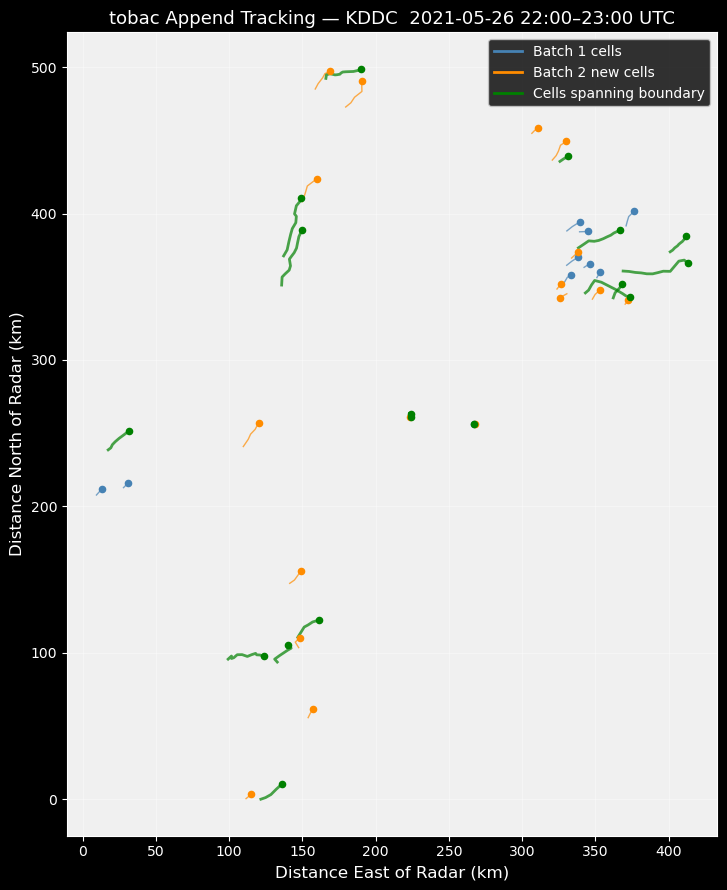

In [13]:
# Identify which cells span the batch boundary
b1_last_time = tracks_batch1["time"].max()
b2_first_time = tracks_full[tracks_full["time"] > b1_last_time]["time"].min()

cells_spanning = set(
    tracks_full[
        (tracks_full["time"] <= b1_last_time) & (tracks_full["cell"] != -1)
    ]["cell"].unique()
) & set(
    tracks_full[
        (tracks_full["time"] >= b2_first_time) & (tracks_full["cell"] != -1)
    ]["cell"].unique()
)

fig, ax = plt.subplots(figsize=(10, 9))
ax.set_facecolor("#f0f0f0")

for cell, group in tracks_full[tracks_full["cell"] != -1].groupby("cell"):
    x_track = group["hdim_2"].values * dxy / 1000   # convert to km
    y_track = group["hdim_1"].values * dxy / 1000

    if cell in cells_spanning:
        color, lw, zorder, label = "green", 2.0, 3, "Spans boundary"
    elif group["time"].max() <= b1_last_time:
        color, lw, zorder, label = "steelblue", 1.0, 2, "Batch 1"
    else:
        color, lw, zorder, label = "darkorange", 1.0, 2, "Batch 2"

    ax.plot(x_track, y_track, color=color, lw=lw, zorder=zorder, alpha=0.7)
    ax.scatter(x_track[-1], y_track[-1], color=color, s=20, zorder=zorder + 1)

# legend
from matplotlib.lines import Line2D
legend_elements = [
    Line2D([0], [0], color="steelblue",  lw=2, label=f"Batch 1 cells"),
    Line2D([0], [0], color="darkorange", lw=2, label=f"Batch 2 new cells"),
    Line2D([0], [0], color="green",      lw=2, label=f"Cells spanning boundary"),
]
ax.legend(handles=legend_elements, loc="upper right", fontsize=10)

ax.set_xlabel("Distance East of Radar (km)", fontsize=12)
ax.set_ylabel("Distance North of Radar (km)", fontsize=12)
ax.set_title(
    f"tobac Append Tracking — {nexrad_site}  "
    f"{window_start.strftime('%Y-%m-%d %H:%M')}–{window_end.strftime('%H:%M')} UTC",
    fontsize=13
)
ax.set_aspect("equal")
ax.grid(True, alpha=0.4)

plt.tight_layout()
plt.savefig("/Users/seanfreeman/PycharmProjects/tobac/examples/Example_Append_Tracking_Radar/Example_Append_Tracking_Radar.png")
plt.show()